# SPECTER2: first embeddings

Embed a handful of known papers and check that the similarities make sense before touching the corpus.

Then check, on the real corpus, what text should go into the model.

In [1]:
import sys
import time

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import torch
from adapters import AutoAdapterModel
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer

sys.path.insert(0, "../scripts")
from ingest import corpus

## Load the model

SPECTER2 is the `specter2_base` model plus the `specter2` (proximity) adapter, loaded with the `adapters` library rather than sentence-transformers.

In [2]:
tokenizer = AutoTokenizer.from_pretrained("allenai/specter2_base")
model = AutoAdapterModel.from_pretrained("allenai/specter2_base")
model.load_adapter("allenai/specter2", source="hf", load_as="specter2", set_active=True)

device = "cuda" if torch.cuda.is_available() else "cpu"  # the GPU, if torch was installed with CUDA support
model.to(device)

print(model.active_adapters, "on", device)  # expect Stack[specter2]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Stack[specter2] on cuda


In [3]:
def embed(papers):
    """Return one 768-number vector per paper: the [CLS] token of title [SEP] abstract."""
    texts = [p["title"] + tokenizer.sep_token + (p.get("abstract") or "") for p in papers]
    inputs = tokenizer(texts, padding=True, truncation=True,
                       return_tensors="pt", return_token_type_ids=False, max_length=512).to(device)
    with torch.no_grad():  # inference only, so skip the bookkeeping needed for training
        output = model(**inputs)
    return output.last_hidden_state[:, 0, :].cpu().numpy()  # back to the CPU, where numpy works


def similarity_table(embeds, names):
    return pd.DataFrame(cosine_similarity(embeds), index=names, columns=names).round(3)

## Test papers

Chosen to separate topic from method: INLA SDM papers, INLA papers outside SDMs, a non-INLA SDM paper, and something unrelated.

In [4]:
papers = [{'title': 'Spatial species distribution models: Using Bayes inference with INLA and SPDE to improve the tree species choice for important European tree species', 'abstract': 'Species distribution models (SDMs) are a standard tool for predicting species occurrence under climate change. Despite its limitations, SDMs have been widely used to assist forest management decisions in their choice of future tree species. The accuracy of SDMs is often affected by heterogeneous occurrence data caused by different forest inventory schemes, historical processes, climate and insect calamities and more. These processes bias the relationships modelled between species occurrence and climate. However, numerous studies have shown that explicit modelling of spatial effects may improve model accuracy. In this study, we applied the Integrated Nested Laplace Approximation (INLA) and Stochastic Partial Differential Equations (SPDE) algorithms as a means to accomplish Bayes inference for Generalized Additive Models (GAMs) with explicit modelling of spatial effects. Our results show that including spatial effects in GAM-based SDMs improved model performance and accuracy leading to more reliable predictions for the species Favorability. Conditional predictions that remove spatial effects from the models allow us to distinguish core and marginal ecological ranges with less bias through forest management, which may support the tree-species choice for climate-resilient forests.'},
          {'title': 'Integrated species distribution models fitted in INLA are sensitive to mesh parameterisation', 'abstract': ' The ever-growing popularity of citizen science, as well as recent technological and digital developments, have allowed the collection of data on species distributions at an extraordinary rate. In order to take advantage of these data, information of varying quantity and quality needs to be integrated. Point process models have been proposed as an elegant way to achieve this for estimates of species distributions. These models can be fitted efficiently using Bayesian methods based on integrated nested Laplace approximations (INLA) with stochastic partial differential equations (SPDEs). This approach uses an efficient way to model spatial autocorrelation using a Gaussian random field and a triangular mesh over the spatial domain. The mesh is constructed by user-defined variables, so effectively represents a free parameter in the model. However, there is a lack of understanding about how to set these mesh parameters, and their effect on model performance. Here, we assess how mesh parameters affect predictions and model fit to estimate the distribution of the serotine bat, Eptesicus serotinus, in Great Britain. A Bayesian INLA model was fitted using five meshes of varying densities to a dataset comprising both structured observations from a national monitoring programme and opportunistic records. We demonstrate that mesh density impacted spatial predictions with a general loss of accuracy with increasing mesh coarseness. However, we also show that the finest mesh was unable to overcome spatial biases in the data. In addition, the magnitude of the covariate effects differed markedly between meshes. This confirms that mesh parameterisation is an important and delicate process with implications for model inference. We discuss how species distribution modellers might adapt their use of INLA in the light of these findings.'},
          {'title': 'Spatio-temporal data integration for species distribution modelling in R-INLA', 'abstract': 'Species distribution modelling is a highly used tool for understanding and predicting biodiversity change, and recent work has emphasised the importance of understanding how species distributions change over both time and space. Spatio-temporal models require large amounts of data spread over time and space, and as such are clear candidates to benefit from model-based integration of different data sources. However, spatio-temporal models are highly computationally intensive and integrating different data sources can make this approach even more unfeasible to ecologists. Here we demonstrate how the R-INLA methodology can be used for model-based data integration for spatio-temporally explicit modelling of species distribution change. We demonstrate that this method can be applied to both point and areal data with two contrasting case studies, one using the SPDE approach for modelling spatio-temporal change in the Gatekeeper butterfly (Pyronia tithonus) across Great Britain and the second using a spatio-temporal areal model to describe change in caddisfly (Trichoptera) populations across the River Thames catchment. We show that in the caddisfly case study integrating together different data sources led to greater understanding of the change in abundance across the River Thames both seasonally and over 5 years of data. However, in the butterfly case study moving to a spatio-temporal context exacerbated differences between the data sources and resulted in no greater ecological insight into change in the Gatekeeper population. Our work provides a computationally feasible framework for spatio-temporally explicit integration of data within SDMs and demonstrates both the potential benefits and the challenges in applying this methodology to real ecological data.'},
          {'title': 'Spatio-temporal disease mapping using INLA', 'abstract': 'Spatio-temporal disease mapping models are a popular tool to describe the pattern of disease counts. They are usually formulated in a hierarchical Bayesian framework with latent Gaussian model. So far, computationally expensive Markov chain Monte Carlo algorithms have been used for parameter estimation which might induce a large Monte Carlo error. An alternative method using integrated nested Laplace approximations (INLA) has recently been proposed. A major advantage of INLA is that it returns accurate parameter estimates in short computational time. Additionally, the deviance information criterion is provided for Bayesian model choice. This paper describes how several parametric and nonparametric models and extensions thereof can be fitted to space–time count data using INLA. Particular emphasis is given to the appropriate choice of linear constraints to ensure identifiability of the parameter estimates. The models are applied to counts of Salmonellosis in cattle reported to the Swiss Federal Veterinary Office 1991–2008. Copyright © 2010 John Wiley & Sons, Ltd.'},
          {'title': 'Direct fitting of dynamic models using integrated nested Laplace approximations — INLA', 'abstract': 'Inference in state-space models usually relies on recursive forms for filtering and smoothing of the state vectors regarding the temporal structure of the observations, an assumption that is, from our view point, unnecessary if the dataset is fixed, that is, completely available before analysis. In this paper, we propose a computational framework to perform approximate full Bayesian inference in linear and generalized dynamic linear models based on the Integrated Nested Laplace Approximation (INLA) approach. The proposed framework directly approximates the posterior marginals of interest disregarding the assumption of recursive updating/estimation of the states and hyperparameters in the case of fixed datasets and, therefore, enable us to do fully Bayesian analysis of complex state-space models more easily and in a short computational time. The proposed framework overcomes some limitations of current tools in the dynamic modeling literature and is vastly illustrated with a series of simulated as well as well known real-life examples from the literature, including realistically complex models with correlated error structures and models with more than one state vector, being mutually dependent on each other. R code is available online for all the examples presented.'},
          {'title': 'Efficacy of species distribution models (SDMs) for ecological realms to ascertain biological conservation and practices', 'abstract': 'SDMs are not new to conservation, but their popularity has increased dramatically in recent years. This step-by-step review provides an overview of the efficacy of SDMs in guiding restoration and conservation strategies across a wide range of ecological realms. Numerous studies have demonstrated the applicability of SDMs to various fields; however, their effectiveness has not been evaluated for a variety of ecosystems. Therefore, a survey and analysis of published work on the use of SDM in ecological rejuvenation and conservation from 2002 to 2023 (May) is conducted. The analysis found a total of 739 papers and the number of papers increased after 2016. The United States of America (135) had the most SDM implementations in conservation planning, followed by China (59), Australia (40), and other nations, according to the classification of the research area by country. In the model, Maxent (341) and in the areas, Forest (252) outperformed contenders for the number of papers published. This review will create a framework to aid in the following: (1) information about taxa and realms in need of protection, (2) selection of the best SDM approach according to study aim, focused species, and study area, and (3) supplemental techniques useful for better SDM output. In addition, it will discuss the advantages and disadvantages of various fundamental SDM algorithms in the context of ecological conservation.'},
          {'title': 'Impacts of bat use of anthropogenic structures on bats and humans', 'abstract': 'Human-induced landscape modifications and climate change are forcing wildlife into closer contact with humans as the availability of natural habitats decreases. Although the importance of anthropogenic structures for the conservation of species is widely recognized, negative narratives surrounding bats may impede conservation efforts in human-dominated landscapes. We conducted a global systematic literature review to summarize research pertaining to bats in anthropogenic structures and analyze the impacts of occupancy of these structures on bats and humans. We extracted data from 735 publications and included 8 that provided a total of 29 quantitative estimates in meta-analyses assessing the consequences of roost selection by bats in anthropogenic and natural habitats. Additionally, information from all 735 publications was used for summaries. Research focused on the Northern Hemisphere, despite the highest diversity of bat species occurring near the equator. Of the 13 identified impacts on bats from the use of anthropogenic structures, disturbance (caused by, e.g., visitation, renovations, artificial lighting) was the most frequently reported. Effects of bat presence on humans were primarily associated with pathogens or other microorganisms of zoonotic interest. Buildings were the most frequently identified anthropogenic roost, and the use of buildings differed across biogeographic realms. Although impacts varied across realms and structures, the Nearctic and Palearctic had the highest incidence of impacts. Few studies compared anthropogenic roosts with natural roosts, but our meta-analyses broadly identified differences in the effects of artificial versus natural roosts on bat behavior, roost temperature, and bat health and occupancy. We found that research is not focused currently on areas where bat–human interactions are most likely to intensify with the growing rate of urbanization. Although many effects on bats from roosting in anthropogenic structures were documented or mentioned, most studies did not measure these effects and few compared them with natural roosts. Quantifying impacts could help in the design of management practices that would benefit bats and humans.'}]

names = ["INLA trees", "INLA ISDM mesh", "INLA spatio-temporal SDM", "INLA disease mapping",
         "INLA dynamic models", "SDM review (no INLA)", "Bats"]
assert len(names) == len(papers)

## Similarities with the adapter

In [5]:
embeds = embed(papers)
print(embeds.shape)  # expect (7, 768)
similarity_table(embeds, names)

(7, 768)


,INLA trees,INLA ISDM mesh,INLA spatio-temporal SDM,INLA disease mapping,INLA dynamic models,SDM review (no INLA),Bats
INLA trees,1.000,0.921,0.902,0.893,0.901,0.931,0.867
INLA ISDM mesh,0.921,1.000,0.927,0.911,0.916,0.891,0.887
INLA spatio-temporal SDM,0.902,0.927,1.000,0.893,0.880,0.890,0.855
INLA disease mapping,0.893,0.911,0.893,1.000,0.927,0.856,0.865
INLA dynamic models,0.901,0.916,0.880,0.927,1.000,0.869,0.856
SDM review (no INLA),0.931,0.891,0.890,0.856,0.869,1.000,0.886
Bats,0.867,0.887,0.855,0.865,0.856,0.886,1.000


## Findings: test papers

- **Ordering is sensible; scale is compressed.** The bats paper is least similar to everything, but scores sit in 0.85–0.93. Judge by rank, not raw score: a score means nothing without the other scores for the same query.
- **Topic and method compete.** "INLA trees" is nearest the non-INLA SDM review (0.931), while "INLA disease mapping" groups with the other INLA papers. SPECTER2 sees both "SDM" and "INLA"; which wins depends on the abstract. For the review, "SDMs *using INLA*" is an intersection embeddings will blur, so keyword matching on INLA (hybrid search, Stage 4) will matter. First entry for the evaluation set.
- **The load-time warning is spurious.** The embeddings change when the adapter is switched off, so it was active.

## Corpus checks: what text goes into the model

Token lengths, languages, titles and junk abstracts, on the real data. The connection is read-only; the last cell closes it.

In [6]:
con = duckdb.connect(corpus["db_path"], read_only=True)

### Token lengths

A random sample of 10,000 works, seeded so it is the same on every run, kept to the English and NULL-language works that will be embedded first (about 8,500). Tokenized without truncation, so the counts show what the 512-token limit would cut.

In [7]:
samp = con.sql("""
    SELECT title, abstract
    FROM (SELECT * FROM works USING SAMPLE reservoir(10000 ROWS) REPEATABLE (42))
    WHERE language = 'en' OR language IS NULL
""").df().dropna()  # drops the few works with no title

samp["title_tokens"] = [len(ids) for ids in tokenizer(list(samp["title"]))["input_ids"]]
samp["abstract_tokens"] = [len(ids) for ids in tokenizer(list(samp["abstract"]))["input_ids"]]

# What the model actually sees, as built in embed()
inputs = samp["title"] + tokenizer.sep_token + samp["abstract"]
samp["input_tokens"] = [len(ids) for ids in tokenizer(list(inputs))["input_ids"]]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

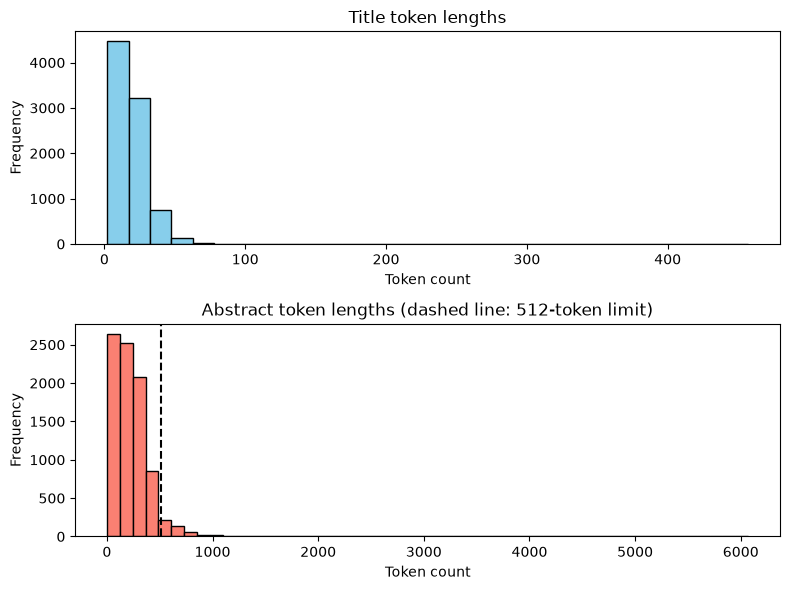

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].hist(samp["title_tokens"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Title token lengths")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Frequency")

axes[1].hist(samp["abstract_tokens"], bins=50, color="salmon", edgecolor="black")
axes[1].axvline(512, color="black", linestyle="--")
axes[1].set_title("Abstract token lengths (dashed line: 512-token limit)")
axes[1].set_xlabel("Token count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

524 of 8613 inputs are over 512 tokens (6.08%)
Median tokens cut from those: 178.5


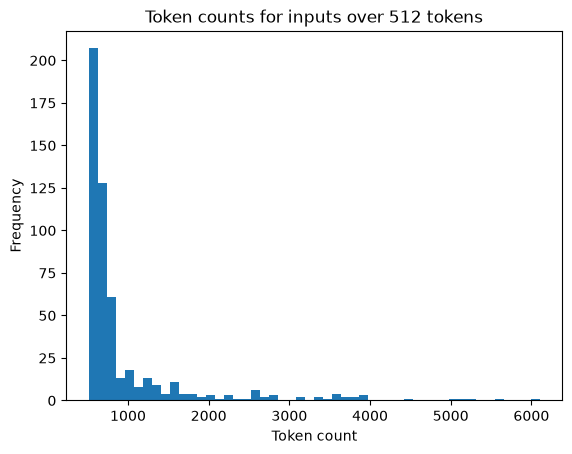

In [9]:
over = samp[samp["input_tokens"] > 512]
print(f"{len(over)} of {len(samp)} inputs are over 512 tokens ({len(over) / len(samp):.2%})")
print("Median tokens cut from those:", (over["input_tokens"] - 512).median())

plt.hist(over["input_tokens"], bins=50)
plt.title("Token counts for inputs over 512 tokens")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.show()

In [10]:
# The longest: real abstracts, or something else?
long = samp[samp["input_tokens"] > 1000].sort_values("input_tokens", ascending=False)

for row in long.head(10).itertuples():
    print(row.input_tokens, "|", row.title, "\n", row.abstract[:1500], "\n")

6102 | Reviewer #2 (Public Review): A Vibrio cholerae viral satellite maximizes its spread and inhibits phage by remodeling hijacked phage coat proteins into small capsids 
 Full text Figures and data Side by side Abstract eLife assessment Introduction Results Discussion Materials and methods Data availability References Peer review Article and author information Abstract Phage satellites commonly remodel capsids they hijack from the phages they parasitize, but only a few mechanisms regulating the change in capsid size have been reported. Here, we investigated how a satellite from Vibrio cholerae, phage-inducible chromosomal island-like element (PLE), remodels the capsid it has been predicted to steal from the phage ICP1 (Netter et al., 2021). We identified that a PLE-encoded protein, TcaP, is both necessary and sufficient to form small capsids during ICP1 infection. Interestingly, we found that PLE is dependent on small capsids for efficient transduction of its genome, making it the f

### Languages

In [11]:
con.sql("SELECT language, count(*) AS n FROM works GROUP BY 1 ORDER BY n DESC").show()

┌──────────┬─────────┐
│ language │    n    │
│ varchar  │  int64  │
├──────────┼─────────┤
│ en       │ 2123173 │
│ NULL     │  147008 │
│ fr       │   76172 │
│ es       │   60227 │
│ pt       │   51996 │
│ vi       │   45353 │
│ de       │   27625 │
│ id       │   18773 │
│ ru       │   13565 │
│ ja       │   13019 │
│ ·        │       · │
│ ·        │       · │
│ ·        │       · │
│ ny       │       1 │
│ lkh      │       1 │
│ co       │       1 │
│ sp       │       1 │
│ zz       │       1 │
│ dv       │       1 │
│ fo       │       1 │
│ por      │       1 │
│ rw       │       1 │
│ gn       │       1 │
└──────────┴─────────┘
       173 rows     
      (20 shown)     



In [12]:
# Are NULL-language works mostly English?
con.sql("""
    SELECT left(title, 80) AS title, left(abstract, 120) AS abstract_start
    FROM works
    WHERE language IS NULL
    ORDER BY random()
    LIMIT 20
""").show(max_width=220)

┌──────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                      title                                       │                                                      abstract_start                                                      │
│                                     varchar                                      │                                                         varchar                                                          │
├──────────────────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Discussion                                                                       │ Discussion of results and data analysis                                            

### Titles

Works with a NULL title (5,300) were supplementary-file records, journal-issue records, or duplicates of titled works. They are deleted from the database, and the ingest skips them. Works with an empty-string title (403) are mostly real papers with missing metadata, so they are kept and embedded from their abstract.

In [13]:
con.sql("""
    SELECT count(*) FILTER (WHERE title IS NULL) AS null_title,
           count(*) FILTER (WHERE trim(title) = '') AS empty_title
    FROM works
""").show()

┌────────────┬─────────────┐
│ null_title │ empty_title │
│   int64    │    int64    │
├────────────┼─────────────┤
│          0 │         403 │
└────────────┴─────────────┘



### Junk abstracts

Two signals: very short abstracts, and abstract text shared by many works (boilerplate). Counted over the whole corpus.

In [14]:
con.sql("""
    WITH w AS (
        SELECT length(trim(abstract)) AS len,
               count(*) OVER (PARTITION BY trim(abstract)) AS n_same  -- works sharing this exact abstract
        FROM works
    )
    SELECT count(*) AS total,
           count(*) FILTER (WHERE len < 10) AS lt10,
           count(*) FILTER (WHERE len < 30) AS lt30,
           count(*) FILTER (WHERE len < 50) AS lt50,
           count(*) FILTER (WHERE len < 100) AS lt100,
           count(*) FILTER (WHERE n_same >= 5) AS repeated_5plus,
           count(*) FILTER (WHERE len < 50 OR n_same >= 5) AS title_only
    FROM w
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬───────┬───────┬───────┬────────┬────────────────┬────────────┐
│  total  │ lt10  │ lt30  │ lt50  │ lt100  │ repeated_5plus │ title_only │
│  int64  │ int64 │ int64 │ int64 │ int64  │     int64      │   int64    │
├─────────┼───────┼───────┼───────┼────────┼────────────────┼────────────┤
│ 2650228 │ 11127 │ 52592 │ 69315 │ 122304 │         147168 │     170074 │
└─────────┴───────┴───────┴───────┴────────┴────────────────┴────────────┘



In [15]:
# The most repeated abstracts: boilerplate, not abstracts
con.sql("""
    SELECT left(trim(abstract), 100) AS abstract_start, count(*) AS n
    FROM works
    GROUP BY trim(abstract)
    ORDER BY n DESC
    LIMIT 20
""").show(max_width=200)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────┐
│                                                                             abstract_start                                                                              │   n   │
│                                                                                 varchar                                                                                 │ int64 │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───────┤
│ Established in 1964, the IUCN Red List of Threatened Species has evolved to become the world’s most                                                                     │ 68658 │
│ International audience                                                                            

In [16]:
# Examples either side of the 50-character cutoff
con.sql("""
    SELECT * FROM (
        SELECT length(trim(abstract)) AS len, trim(abstract) AS abstract, left(title, 60) AS title
        FROM works
        WHERE length(trim(abstract)) BETWEEN 30 AND 99
        ORDER BY random()
        LIMIT 20
    )
    ORDER BY len
""").show(max_width=250)

┌───────┬─────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────┐
│  len  │                                            abstract                                             │                               title                                │
│ int64 │                                             varchar                                             │                              varchar                               │
├───────┼─────────────────────────────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────────────────────────┤
│    33 │ Bulk uploaded via High-Speed Tool                                                               │ 美式书海狸宾尼和其他故事(Binney the beaver, and other stories).pdf │
│    37 │ Criminology as an Applied Science - 1                                                           │ The sub-sciences of

## Timing

How long would the full run take on this machine? A random sample of the works to embed, built the way the run will build them: English and NULL language, with junk abstracts replaced by an empty string so the work is embedded from its title alone. The junk rule is the one above, written as a lookup list of repeated texts.

Sized for the GPU. On a CPU, cut the sample to a couple of hundred works, or the timing takes about an hour.

In [17]:
timing_works = con.sql("""
    WITH repeated AS (  -- boilerplate: the same abstract text on 5 or more works
        SELECT trim(abstract) AS text
        FROM works
        WHERE abstract IS NOT NULL
        GROUP BY 1
        HAVING count(*) >= 5
    ),
    to_embed AS (
        SELECT work_id, title,
               CASE WHEN length(trim(coalesce(abstract, ''))) < 50
                         OR trim(abstract) IN (SELECT text FROM repeated)
                    THEN ''  -- junk abstract: embed the title alone
                    ELSE abstract
               END AS abstract
        FROM works
        WHERE language = 'en' OR language IS NULL
    )
    SELECT * FROM to_embed USING SAMPLE 2000 ROWS
""").df().to_dict("records")  # a list of {"work_id": ..., "title": ..., "abstract": ...}, the shape embed() takes

print(len(timing_works), "works;", sum(w["abstract"] == "" for w in timing_works), "embedded from the title alone")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2000 works; 102 embedded from the title alone


In [18]:
def works_per_second(works, batch_size):
    """Embed works in batches of batch_size; return the number of works embedded per second."""
    start = time.perf_counter()
    n_vectors = 0
    for i in range(0, len(works), batch_size):
        n_vectors += len(embed(works[i:i + batch_size]))  # the last slice is just shorter, no error
    seconds = time.perf_counter() - start
    assert n_vectors == len(works)  # one vector per work
    return len(works) / seconds

In [19]:
embed(timing_works[:8])  # warm-up: the first call is always slower, so keep it out of the timings

# Sorting by length puts similar lengths in the same batch, so there is less padding.
# Characters are a cheap stand-in for tokens.
by_length = sorted(timing_works, key=lambda w: len(w["title"]) + len(w["abstract"]))

timings = []
for batch_size in [16, 64, 128]:
    for order, works in [("random", timing_works), ("sorted by length", by_length)]:
        rate = works_per_second(works, batch_size)
        timings.append({"batch_size": batch_size, "order": order, "works_per_second": round(rate, 1)})
        print(timings[-1])  # show progress, since each run takes a while

timings = pd.DataFrame(timings)

{'batch_size': 16, 'order': 'random', 'works_per_second': 83.9}
{'batch_size': 16, 'order': 'sorted by length', 'works_per_second': 125.3}
{'batch_size': 64, 'order': 'random', 'works_per_second': 79.0}
{'batch_size': 64, 'order': 'sorted by length', 'works_per_second': 95.9}
{'batch_size': 128, 'order': 'random', 'works_per_second': 79.8}
{'batch_size': 128, 'order': 'sorted by length', 'works_per_second': 103.7}


In [20]:
n_to_embed = con.sql("SELECT count(*) FROM works WHERE language = 'en' OR language IS NULL").fetchone()[0]
best = timings.loc[timings["works_per_second"].idxmax()]
hours = n_to_embed / best["works_per_second"] / 3600

print(f"{n_to_embed:,} works to embed on {device}. Best rate: {best['works_per_second']} works/s "
      f"(batch size {best['batch_size']}, {best['order']}), so about {hours:,.1f} hours.")
timings

2,270,181 works to embed on cuda. Best rate: 125.3 works/s (batch size 16, sorted by length), so about 5.0 hours.


,batch_size,order,works_per_second
0,16,random,83.9
1,16,sorted by length,125.3
2,64,random,79.0
3,64,sorted by length,95.9
4,128,random,79.8
5,128,sorted by length,103.7


## Decisions

- **Input: `title [SEP] abstract`, one vector per work** matching SPECTER2's training format
- **Truncate at 512 tokens, no chunking.** About 6% of English and NULL-language inputs (title [SEP] abstract, random sample) are over the limit, and for those the median cut is 150–180 tokens from the end of the abstract. Chunking would mean several vectors per paper, and inputs unlike the training data.
- **Languages: embed English and NULL first.** A sample of 20 NULL-language works was mostly English. Other languages can be added later by rerunning with a wider filter, since the run skips works already embedded.
- **Junk abstracts: embed the title alone, never drop the work.** Title only when `length(trim(abstract)) < 50` or the exact abstract text appears in 5 or more works. That covers 170,074 works (6.4%). Below 50 characters there are essentially no real abstracts; repeats of 2–4 are mostly real (preprint plus published version). The repeats are boilerplate: 68,658 IUCN Red List entries share one text, then publisher and repository blurbs.
- **Works with a NULL title are deleted, and the ingest skips them.** All 5,300 were supplementary-file records, journal-issue records, or duplicates of titled works. The 403 works with an empty-string title are mostly real papers, so they are kept and embedded from their abstract.
- **The corpus includes non-papers** (Red List entries, GBIF downloads, CABI datasheets, figures, datasets). OpenAlex's `type` field would filter them but was not fetched; adding it means a full re-download (~13k credits).
- **Embed on the GPU, batch size 16, sorted by length.** With the CUDA build of torch on the RTX 2080 Ti, the best rate was about 126 works per second, so ~5 hours for the 2,270,181 English and NULL works. Bigger batches were slower (about 100 works per second at 128, sorted): the GPU is already busy at 16, so bigger batches only add padding.

## Close

In [21]:
con.close()  # release the database file so a script can write to it